# Comparação entre métricas normadas e a distância intrínseca no grafo de ruas

**Estudo de caso:** Ciclo Básico Unicamp → Terminal Barão Geraldo, seguido de um experimento estatístico com 10.000 pares de vértices em Campinas.

Este notebook usa o pacote `nao_e_so_reta`, que concentra as funções de download/carregamento do grafo, projeção métrica, cálculo de menor caminho, cálculo das métricas $L^p$, amostragem de pares, estatísticas de erro e geração de gráficos.

A ideia matemática é comparar a distância intrínseca do grafo de ruas,

$$d_G(u,v) = \min_{\gamma:u\to v}\sum_{e\in \gamma}\ell(e),$$

com distâncias induzidas por normas em $\mathbb{R}^2$:

$$d_p(x,y)=\left(|x_1-y_1|^p+|x_2-y_2|^p\right)^{1/p},$$

incluindo os casos $p=1$, $p=2$, $p=1.54$, outros valores fixos de $p$, e $p=\infty$:

$$d_\infty(x,y)=\max\{|x_1-y_1|, |x_2-y_2|\}.$$

As coordenadas são projetadas para um CRS métrico antes do cálculo das distâncias planas. Isso é essencial: latitude/longitude estão em graus, não em metros.

## 1. Instalação

In [8]:
from pathlib import Path
import sys
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import nao_e_so_reta as sm

print(f"Diretório do projeto: {PROJECT_ROOT}")


Diretório do projeto: /home/ABTLUS/thalles24006/Documentos/ILUM/PGMAT/nao-e-so-reta


## 2. Configuração geral do experimento

1. **Caso pontual:** Ciclo Básico Unicamp → Terminal Barão Geraldo.

In [9]:
# Lugares principais
PLACE_CASE = "Barão Geraldo, Campinas, São Paulo, Brazil"
PLACE_STATS = "Campinas, São Paulo, Brazil"

# Pontos do estudo de caso
ORIGIN_QUERY = "Rua Sérgio Buarque de Holanda, 290, Barão Geraldo, Campinas, São Paulo, Brazil"
DESTINATION_QUERY = "R. Alzira de Águiar Aranha, S/N, Jardim Santa Genebra II, Campinas, São Paulo, Brazil"

# Fallbacks.
# Formato: (latitude, longitude).
ORIGIN_FALLBACK_LATLON = (-22.817528, -47.068611)
DESTINATION_FALLBACK_LATLON = (-22.83065, -47.07957)

# Fallback aproximado para baixar um recorte de Barão Geraldo caso PLACE_CASE não resolva como polígono.
# O valor é usado somente se o download por nome falhar.
BARAO_CENTER_LATLON = (-22.8170, -47.0700)
BARAO_DIST_M = 6500

# Rede abstrata de ruas: baixamos a rede de ruas veiculares e depois ignoramos direção das vias.
NETWORK_TYPE = "drive"
MAKE_UNDIRECTED = True

# Valores fixos de p, incluindo p = 1.54.
P_VALUES = sm.DEFAULT_P_VALUES
print(f"Valores de p: {P_VALUES}")

Valores de p: (1.0, 1.25, 1.5, 1.54, 1.75, 2.0, 3.0, 5.0, 10.0, inf)



## 3. Download ou carregamento do grafo de Barão Geraldo

O grafo salvo em `data/graph_barao_geraldo.graphml` é o grafo bruto do OSMnx. Sempre que ele é carregado, o módulo reprojeta o grafo para coordenadas métricas, converte para não direcionado e mantém a maior componente conexa.

Se o nome `Barão Geraldo, Campinas, São Paulo, Brazil` não resolver como polígono no Nominatim, o código tenta baixar um recorte circular com centro e raio definidos acima.


In [10]:
graph_barao_path = "../data/graph.graphml"

try:
    G_barao = sm.load_or_download_graph(
        graph_barao_path,
        place=PLACE_CASE,
        network_type=NETWORK_TYPE,
        make_undirected=MAKE_UNDIRECTED,
        keep_largest_component=True,
    )
    print("Grafo de Barão Geraldo carregado por nome de lugar.")
except Exception as exc:
    print("Falha ao carregar Barão Geraldo por nome de lugar.")
    print("Erro:", repr(exc))
    print("Tentando recorte por ponto central + raio...")
    G_barao = sm.load_or_download_graph(
        graph_barao_path,
        center_point=BARAO_CENTER_LATLON,
        dist=BARAO_DIST_M,
        network_type=NETWORK_TYPE,
        make_undirected=MAKE_UNDIRECTED,
        keep_largest_component=True,
        force_download=True,
    )

print(f"Número de vértices: {len(G_barao.nodes):,}")
print(f"Número de arestas: {len(G_barao.edges):,}")
print("CRS:", G_barao.graph.get("crs"))


Grafo de Barão Geraldo carregado por nome de lugar.
Número de vértices: 2,181
Número de arestas: 3,265
CRS: EPSG:32723



## 4. Estudo pontual: Ciclo Básico Unicamp → Terminal Barão Geraldo

Nesta etapa, os nomes dos locais são geocodificados, substituídos pelos vértices mais próximos do grafo e então comparados por:

- distância intrínseca no grafo, $d_G$;
- $d_1$, $d_2$, $d_\infty$;
- $d_p$ para os demais valores de $p$, incluindo $p=1.54$;
- tortuosidade $d_G/d_2$.


In [11]:
case_result, origin_point, destination_point = sm.compute_single_pair_from_queries(
    G_barao,
    ORIGIN_QUERY,
    DESTINATION_QUERY,
    origin_fallback_latlon=ORIGIN_FALLBACK_LATLON,
    destination_fallback_latlon=DESTINATION_FALLBACK_LATLON,
    p_values=P_VALUES,
)

case_df = sm.single_pair_to_dataframe(case_result)

# Tabela em metros e quilômetros para leitura mais direta.
metric_cols = [c for c in case_df.columns if c.startswith("d_") and c.endswith("_m")]
case_table = case_df[["d_graph_m", "tortuosity_dG_dL2"] + [c for c in metric_cols if c != "d_graph_m"]].T
case_table.columns = ["valor"]
case_table["valor_km_quando_distancia"] = case_table["valor"] / 1000
case_table


/home/ABTLUS/thalles24006/Documentos/ILUM/PGMAT/nao-e-so-reta/src/nao_e_so_reta/routing.py:98: RuntimeWarning: Falha ao geocodificar 'R. Alzira de Águiar Aranha, S/N, Jardim Santa Genebra II, Campinas, São Paulo, Brazil'. Usando fallback_latlon=(-22.83065, -47.07957).
  point = geocode_point(query, fallback_latlon=fallback_latlon)


,valor,valor_km_quando_distancia
d_graph_m,2131.695493,2.131695
tortuosity_dG_dL2,1.234499,0.001234
d_L1_m,2431.902671,2.431903
d_L1_25_m,2119.302808,2.119303
d_L1_5_m,1934.226481,1.934226
d_L1_54_m,1911.467079,1.911467
d_L1_75_m,1812.541830,1.812542
d_L2_m,1726.770019,1.726770
d_L3_m,1544.673154,1.544673
d_L5_m,1419.407593,1.419408


In [12]:
print("Origem geocodificada:")
print(origin_point)
print("\nDestino geocodificado:")
print(destination_point)

print("\nResumo do caso pontual:")
print(f"d_G = {case_result.graph_distance_m/1000:.3f} km")
print(f"vértice origem = {case_result.origin_node}")
print(f"vértice destino = {case_result.destination_node}")
print(f"número de vértices na rota = {len(case_result.route)}")

Origem geocodificada:
(-22.8182776, -47.0689087)

Destino geocodificado:
(-22.83065, -47.07957)

Resumo do caso pontual:
d_G = 2.132 km
vértice origem = 860796288
vértice destino = 914105159
número de vértices na rota = 29



### 4.1. Gráfico da rota

A figura abaixo mostra o menor caminho no grafo para o caso pontual. Ela está salva em `figures/rota_ciclo_terminal.png`.


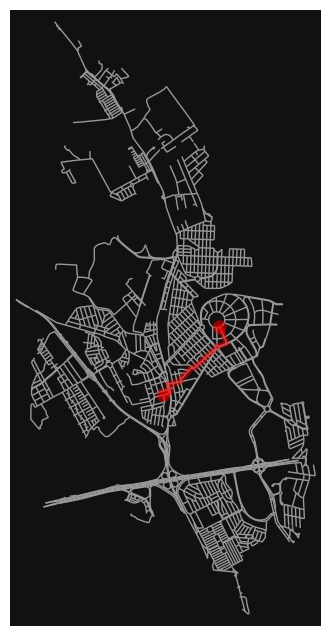

Figura salva em: figures/rota_ciclo_terminal.png


In [13]:
route_fig_path = "figures/rota_ciclo_terminal.png"
fig, ax = sm.plot_route(
    G_barao,
    case_result.route,
    filepath=route_fig_path,
    show=False,
    close=False,
)
plt.show()
print("Figura salva em:", route_fig_path)

In [14]:
USE_CAMPINAS_FOR_STATS = False

if USE_CAMPINAS_FOR_STATS:
    graph_stats_path = "../data/graph.graphml"
    G_stats = sm.load_or_download_graph(
        graph_stats_path,
        place=PLACE_STATS,
        network_type=NETWORK_TYPE,
        make_undirected=MAKE_UNDIRECTED,
        keep_largest_component=True,
    )
else:
    graph_stats_path = "../data/graph.graphml"
    G_stats = G_barao

print(f"Grafo estatístico: {PLACE_STATS if USE_CAMPINAS_FOR_STATS else PLACE_CASE}")
print(f"Número de vértices: {len(G_stats.nodes):,}")
print(f"Número de arestas: {len(G_stats.edges):,}")
print("CRS:", G_stats.graph.get("crs"))

Grafo estatístico: Barão Geraldo, Campinas, São Paulo, Brazil
Número de vértices: 2,181
Número de arestas: 3,265
CRS: EPSG:32723


Interpretação matemática inicial

Alguns pontos para usar na redação do artigo:

1. A distância euclidiana \(d_2\) entre dois vértices é um limite inferior natural para a distância no grafo quando as arestas do grafo representam segmentos ou curvas no plano com comprimento físico. Intuitivamente, qualquer caminho pela rede é um caminho admissível no plano, e o segmento reto é o menor caminho euclidiano.

2. A tortuosidade \(d_G/d_2\) mede o excesso imposto pela malha viária: quão mais longo é o deslocamento na rede em relação à separação euclidiana.

3. As métricas \(L^1\), \(L^p\) e \(L^\infty\) dependem da orientação dos eixos. Em uma malha urbana com direções predominantes, certos valores de \(p\) podem se ajustar melhor à geometria empírica do grafo.

4. Como a comparação aqui é direta, sem calibração multiplicativa, a métrica vencedora é aquela cuja escala e geometria bruta mais se aproximam de \(d_G\) para a amostra escolhida.

5. O valor ótimo de \(p\) deve ser interpretado empiricamente: ele não prova que a cidade “é” um espaço \(L^p\), mas indica qual norma da família \(L^p\) minimiza o erro escolhido sob a amostra e o recorte espacial utilizados.

## Referências práticas usadas no notebook

- OSMnx: biblioteca para baixar, modelar, projetar, analisar e visualizar redes urbanas a partir do OpenStreetMap.
- NetworkX: biblioteca usada para os algoritmos de menor caminho, incluindo Dijkstra em grafos ponderados.
- Ciclo Básico Unicamp: endereço oficial na Rua Sérgio Buarque de Holanda, nº 290.
- Terminal Barão Geraldo – Lázaro de Campos Faria: terminal em Barão Geraldo, Campinas.